## 4.3.3 Dataset Construction

### Customer-Level Dataset Construction and Feature Engineering

In [2]:
import pandas as pd

orders = pd.read_csv("DATA FINAL - selection and cleaning (4_3)_orders.csv", sep=';')
orders.head()

,order_number,e-mail hash,total,paid_at
0,123001,168ef0d099c97ea9c0ac74666da28253f4a94ab5312df6...,23759,02.01.2023 6:27
1,123002,a83daa62571fae55ba8e8151514df2ec7f78803f2333a8...,17499,06.01.2023 10:50
2,123003,dd3451130e4d31afba65592f9e89a72069c8712b1afc12...,7326,02.01.2023 9:26
3,123004,03b8bc9300e94c729b2da1cc1936675a8d0ce8b36f57da...,2457,02.01.2023 6:30
4,123005,d867124aa02cdcab6302748fabb0f206117915b8577cc2...,4868,01.01.2023 14:44


In [3]:
orders.dtypes

order_number     int64
e-mail hash     object
total           object
paid_at         object
dtype: object

In [4]:
orders['paid_at'] = pd.to_datetime(orders['paid_at'], dayfirst=True)

In [5]:
customer_data = orders.groupby('e-mail hash').agg({
    'paid_at': ['min', 'max', 'count'],
    'total': 'sum'
})

In [6]:
orders['total'] = pd.to_numeric(orders['total'], errors='coerce')

In [7]:
orders.dtypes

order_number             int64
e-mail hash             object
total                  float64
paid_at         datetime64[ns]
dtype: object

In [8]:
# aggregate orders to customer level
customer_data = orders.groupby('e-mail hash').agg({
    'paid_at': ['min', 'max', 'count'],
    'total': 'sum'
}).reset_index()

# rename columns
customer_data.columns = [
    'Customer_id',
    'First_Purchase_Date',
    'Last_Purchase_Date',
    'Frequency',
    'Monetary'
]

customer_data.head()

,Customer_id,First_Purchase_Date,Last_Purchase_Date,Frequency,Monetary
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,2025-06-23 14:26:00,2025-06-23 14:26:00,1,2622.0
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,2025-10-17 16:58:00,2025-10-23 05:23:00,2,16503.0
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,2023-11-16 18:23:00,2023-11-16 18:23:00,1,8278.0
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,2025-06-02 22:12:00,2025-06-02 22:12:00,1,973.0
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,2023-07-18 06:56:00,2023-07-18 06:56:00,1,6017.0


In [9]:
# reference date = latest purchase date in the dataset
snapshot_date = orders['paid_at'].max()

# recency = number of days since the last purchase
customer_data['Recency'] = (snapshot_date - customer_data['Last_Purchase_Date']).dt.days

customer_data.head()

,Customer_id,First_Purchase_Date,Last_Purchase_Date,Frequency,Monetary,Recency
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,2025-06-23 14:26:00,2025-06-23 14:26:00,1,2622.0,130
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,2025-10-17 16:58:00,2025-10-23 05:23:00,2,16503.0,9
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,2023-11-16 18:23:00,2023-11-16 18:23:00,1,8278.0,715
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,2025-06-02 22:12:00,2025-06-02 22:12:00,1,973.0,151
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,2023-07-18 06:56:00,2023-07-18 06:56:00,1,6017.0,837


In [10]:
# average value per order
customer_data['Average_Transaction_Value'] = customer_data['Monetary'] / customer_data['Frequency']

customer_data.head()

,Customer_id,First_Purchase_Date,Last_Purchase_Date,Frequency,Monetary,Recency,Average_Transaction_Value
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,2025-06-23 14:26:00,2025-06-23 14:26:00,1,2622.0,130,2622.0
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,2025-10-17 16:58:00,2025-10-23 05:23:00,2,16503.0,9,8251.5
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,2023-11-16 18:23:00,2023-11-16 18:23:00,1,8278.0,715,8278.0
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,2025-06-02 22:12:00,2025-06-02 22:12:00,1,973.0,151,973.0
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,2023-07-18 06:56:00,2023-07-18 06:56:00,1,6017.0,837,6017.0


In [11]:
# customer lifetime in days
customer_data['Customer_Lifetime_Days'] = (
    customer_data['Last_Purchase_Date'] - customer_data['First_Purchase_Date']
).dt.days

customer_data.head()

,Customer_id,First_Purchase_Date,Last_Purchase_Date,Frequency,Monetary,Recency,Average_Transaction_Value,Customer_Lifetime_Days
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,2025-06-23 14:26:00,2025-06-23 14:26:00,1,2622.0,130,2622.0,0
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,2025-10-17 16:58:00,2025-10-23 05:23:00,2,16503.0,9,8251.5,5
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,2023-11-16 18:23:00,2023-11-16 18:23:00,1,8278.0,715,8278.0,0
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,2025-06-02 22:12:00,2025-06-02 22:12:00,1,973.0,151,973.0,0
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,2023-07-18 06:56:00,2023-07-18 06:56:00,1,6017.0,837,6017.0,0


In [12]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24169 entries, 0 to 24168
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Customer_id                24169 non-null  object        
 1   First_Purchase_Date        24169 non-null  datetime64[ns]
 2   Last_Purchase_Date         24169 non-null  datetime64[ns]
 3   Frequency                  24169 non-null  int64         
 4   Monetary                   24169 non-null  float64       
 5   Recency                    24169 non-null  int64         
 6   Average_Transaction_Value  24169 non-null  float64       
 7   Customer_Lifetime_Days     24169 non-null  int64         
dtypes: datetime64[ns](2), float64(2), int64(3), object(1)
memory usage: 1.5+ MB


In [13]:
customer_data.describe()

,First_Purchase_Date,Last_Purchase_Date,Frequency,Monetary,Recency,Average_Transaction_Value,Customer_Lifetime_Days
count,24169,24169,24169.000000,24169.000000,24169.000000,24169.000000,24169.000000
mean,2024-07-12 11:28:55.409822720,2024-08-11 21:52:07.214200064,1.292813,8983.519757,445.903554,6978.524057,30.326658
min,2023-01-01 14:44:00,2023-01-01 14:44:00,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-11-13 00:55:00,2023-12-12 21:41:00,1.000000,2308.000000,165.000000,2168.000000,0.000000
50%,2024-07-22 08:13:00,2024-09-10 02:03:00,1.000000,5208.000000,417.000000,4642.500000,0.000000
75%,2025-04-16 18:59:00,2025-05-19 22:24:00,1.000000,12987.000000,689.000000,9917.000000,0.000000
max,2025-10-30 11:51:00,2025-11-01 10:16:00,92.000000,142486.000000,1034.000000,79049.000000,1030.000000
std,NaN,NaN,0.873512,9296.819394,298.941281,6386.895192,114.746182


In [14]:
customer_data.to_csv("customer_data.csv", index=False)

### Seasonal Dataset Construction

In [15]:
sales = pd.read_csv("DATA FINAL - selection and cleaning (4_3)_sales.csv", sep=';')
sales.head()

,product_type,order_number
0,ipad,300533251
1,product_variant,24317730
2,airpods,686070801
3,iphone,17310070
4,iphone,648139265


In [16]:
seasonal_data = pd.merge(
    orders,
    sales,
    on='order_number',
    how='left'
)

seasonal_data.head()

,order_number,e-mail hash,total,paid_at,product_type
0,123001,168ef0d099c97ea9c0ac74666da28253f4a94ab5312df6...,23759.0,2023-01-02 06:27:00,NaN
1,123002,a83daa62571fae55ba8e8151514df2ec7f78803f2333a8...,17499.0,2023-01-06 10:50:00,NaN
2,123003,dd3451130e4d31afba65592f9e89a72069c8712b1afc12...,7326.0,2023-01-02 09:26:00,NaN
3,123004,03b8bc9300e94c729b2da1cc1936675a8d0ce8b36f57da...,2457.0,2023-01-02 06:30:00,NaN
4,123005,d867124aa02cdcab6302748fabb0f206117915b8577cc2...,4868.0,2023-01-01 14:44:00,NaN


In [17]:
seasonal_data['Month'] = seasonal_data['paid_at'].dt.month
seasonal_data['Year'] = seasonal_data['paid_at'].dt.year

In [18]:
seasonal_data['Quarter'] = seasonal_data['paid_at'].dt.quarter

In [19]:
seasonal_data = seasonal_data.rename(columns={
    'e-mail hash': 'Customer_id'
})

In [20]:
seasonal_data.head()

,order_number,Customer_id,total,paid_at,product_type,Month,Year,Quarter
0,123001,168ef0d099c97ea9c0ac74666da28253f4a94ab5312df6...,23759.0,2023-01-02 06:27:00,NaN,1,2023,1
1,123002,a83daa62571fae55ba8e8151514df2ec7f78803f2333a8...,17499.0,2023-01-06 10:50:00,NaN,1,2023,1
2,123003,dd3451130e4d31afba65592f9e89a72069c8712b1afc12...,7326.0,2023-01-02 09:26:00,NaN,1,2023,1
3,123004,03b8bc9300e94c729b2da1cc1936675a8d0ce8b36f57da...,2457.0,2023-01-02 06:30:00,NaN,1,2023,1
4,123005,d867124aa02cdcab6302748fabb0f206117915b8577cc2...,4868.0,2023-01-01 14:44:00,NaN,1,2023,1


In [21]:
seasonal_data.to_csv("seasonal_data.csv", index=False)

In [22]:
# count missing product_type after merge
seasonal_data['product_type'].isna().sum()

np.int64(6104)

In [23]:
# orders without matching product record
missing_orders = orders[~orders['order_number'].isin(sales['order_number'])]

missing_orders.head()

,order_number,e-mail hash,total,paid_at
0,123001,168ef0d099c97ea9c0ac74666da28253f4a94ab5312df6...,23759.0,2023-01-02 06:27:00
1,123002,a83daa62571fae55ba8e8151514df2ec7f78803f2333a8...,17499.0,2023-01-06 10:50:00
2,123003,dd3451130e4d31afba65592f9e89a72069c8712b1afc12...,7326.0,2023-01-02 09:26:00
3,123004,03b8bc9300e94c729b2da1cc1936675a8d0ce8b36f57da...,2457.0,2023-01-02 06:30:00
4,123005,d867124aa02cdcab6302748fabb0f206117915b8577cc2...,4868.0,2023-01-01 14:44:00


In [24]:
# number of unmatched orders
missing_orders.shape[0]

6104

In [25]:
# number of matched orders
matched_orders = orders[orders['order_number'].isin(sales['order_number'])]
matched_orders.shape[0]

25142

In [26]:
# keep only rows with product information
seasonal_data = seasonal_data.dropna(subset=['product_type']).copy()

seasonal_data.head()

,order_number,Customer_id,total,paid_at,product_type,Month,Year,Quarter
8,162907,e44cc6393b4083277f5b79548f1cfa4605609826a97994...,349.0,2025-05-27 09:25:00,product_variant,5,2025,2
19,390710,d77a38be6dc0014f85550c2333157e00ac998afdff275e...,399.0,2024-12-24 13:59:00,product_variant,12,2024,4
40,805933,2e9bf21606b5e2ccf9d939a4de2dc2eed19e80207412c1...,1299.0,2025-05-17 23:39:00,airpods,5,2025,2
41,849845,8cdfe296a00a3a3872a42f8115fda2a6b13ca79035832d...,15180.0,2024-05-04 15:51:00,iphone,5,2024,2
102,1240002,c901e8ea0c550450511425564a77bb5f63a73e8a0c8f2b...,10588.0,2024-01-01 10:40:00,iphone,1,2024,1


In [27]:
seasonal_data.to_csv("seasonal_data.csv", index=False)

## 4.3.4 – OUTLIER DETECTION & FEATURE SCALING

### Outlier Detection

In [28]:
from sklearn.ensemble import IsolationForest

# select features for outlier detection
features = customer_data[['Recency', 'Frequency', 'Monetary']]

# initialize model
iso = IsolationForest(contamination=0.02, random_state=42)

# fit and predict
customer_data['Outlier'] = iso.fit_predict(features)

# count outliers
customer_data['Outlier'].value_counts()

Outlier
 1    23685
-1      484
Name: count, dtype: int64

In [29]:
# keep only normal observations (1 = normal, -1 = outlier)
customer_data_clean = customer_data[customer_data['Outlier'] == 1].copy()

# drop helper column
customer_data_clean = customer_data_clean.drop(columns=['Outlier'])

customer_data_clean.shape

(23685, 8)

#### Feature Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

# select features for scaling
features = customer_data_clean[['Recency', 'Frequency', 'Monetary']]

# initialize scaler
scaler = StandardScaler()

# scale features
scaled_features = scaler.fit_transform(features)

# create dataframe
customer_data_scaled = pd.DataFrame(
    scaled_features,
    columns=['Recency', 'Frequency', 'Monetary']
)

customer_data_scaled.head()

,Recency,Frequency,Monetary
0,-1.061838,-0.457406,-0.737092
1,-1.466933,1.436590,1.060849
2,0.896678,-0.457406,-0.004497
3,-0.991533,-0.457406,-0.950679
4,1.305121,-0.457406,-0.297354


In [31]:
customer_data_scaled['Customer_id'] = customer_data_clean['Customer_id'].values

In [32]:
customer_data_scaled.head()

,Recency,Frequency,Monetary,Customer_id
0,-1.061838,-0.457406,-0.737092,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...
1,-1.466933,1.436590,1.060849,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...
2,0.896678,-0.457406,-0.004497,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...
3,-0.991533,-0.457406,-0.950679,001d8b397484e2ce67c42250613c10976bea11cc77f413...
4,1.305121,-0.457406,-0.297354,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...


In [33]:
customer_data_scaled = customer_data_scaled[
    ['Customer_id', 'Recency', 'Frequency', 'Monetary']
]

# 4.4 Modelling

## 4.4.1 RFM Analysis

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

# set plot style
sns.set_style("whitegrid")

In [35]:
# create RFM dataframe from customer-level dataset
rfm_df = customer_data[['Customer_id', 'Recency', 'Frequency', 'Monetary']].copy()

# preview data
rfm_df.head()

,Customer_id,Recency,Frequency,Monetary
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,130,1,2622.0
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,9,2,16503.0
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,715,1,8278.0
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,151,1,973.0
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,837,1,6017.0


In [36]:
# calculate quintiles for Recency, Frequency, and Monetary
quantiles_recency = rfm_df['Recency'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()
quantiles_frequency = rfm_df['Frequency'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()
quantiles_monetary = rfm_df['Monetary'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()

In [37]:
# assign RFM scores based on quintiles
def assign_rfm_scores_quantiles(recency, frequency, monetary):
    
    # recency: lower value = better
    if recency <= quantiles_recency[0]:
        r_score = 5
    elif recency <= quantiles_recency[1]:
        r_score = 4
    elif recency <= quantiles_recency[2]:
        r_score = 3
    elif recency <= quantiles_recency[3]:
        r_score = 2
    else:
        r_score = 1

    # frequency: higher value = better
    if frequency <= quantiles_frequency[0]:
        f_score = 1
    elif frequency <= quantiles_frequency[1]:
        f_score = 2
    elif frequency <= quantiles_frequency[2]:
        f_score = 3
    elif frequency <= quantiles_frequency[3]:
        f_score = 4
    else:
        f_score = 5

    # monetary: higher value = better
    if monetary <= quantiles_monetary[0]:
        m_score = 1
    elif monetary <= quantiles_monetary[1]:
        m_score = 2
    elif monetary <= quantiles_monetary[2]:
        m_score = 3
    elif monetary <= quantiles_monetary[3]:
        m_score = 4
    else:
        m_score = 5

    return r_score, f_score, m_score

In [38]:
# apply scoring function to each customer
rfm_df[['R_Score', 'F_Score', 'M_Score']] = rfm_df.apply(
    lambda x: assign_rfm_scores_quantiles(x['Recency'], x['Frequency'], x['Monetary']),
    axis=1,
    result_type='expand'
)

# preview scored data
rfm_df.head()

,Customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,130,1,2622.0,4,1,2
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,9,2,16503.0,5,4,5
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,715,1,8278.0,2,1,4
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,151,1,973.0,4,1,1
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,837,1,6017.0,1,1,3


In [39]:
# create combined RFM score
rfm_df['RFM_Score'] = (
    rfm_df['R_Score'].astype(str) +
    rfm_df['F_Score'].astype(str) +
    rfm_df['M_Score'].astype(str)
)

# create aggregated numerical score
rfm_df['RFM_Combined'] = (
    rfm_df['R_Score'].astype(int) +
    rfm_df['F_Score'].astype(int) +
    rfm_df['M_Score'].astype(int)
)

# preview updated dataframe
rfm_df.head()

,Customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Combined
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,130,1,2622.0,4,1,2,412,7
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,9,2,16503.0,5,4,5,545,14
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,715,1,8278.0,2,1,4,214,7
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,151,1,973.0,4,1,1,411,6
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,837,1,6017.0,1,1,3,113,5


In [40]:
# assign customer segments based on aggregated RFM score
def assign_segment(rfm_combined):
    if rfm_combined >= 13:
        return 'Champions'
    elif rfm_combined >= 10:
        return 'Loyal Customers'
    elif rfm_combined >= 7:
        return 'Potential Loyalists'
    elif rfm_combined >= 5:
        return 'Promising'
    elif rfm_combined == 4:
        return 'At Risk'
    else:
        return 'Hibernating'

# create customer segment column
rfm_df['Customer_Segment'] = rfm_df['RFM_Combined'].apply(assign_segment)

# preview segmented customers
rfm_df.head()

,Customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Combined,Customer_Segment
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,130,1,2622.0,4,1,2,412,7,Potential Loyalists
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,9,2,16503.0,5,4,5,545,14,Champions
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,715,1,8278.0,2,1,4,214,7,Potential Loyalists
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,151,1,973.0,4,1,1,411,6,Promising
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,837,1,6017.0,1,1,3,113,5,Promising


In [41]:
# count customers in each RFM segment
customer_segment_counts = rfm_df['Customer_Segment'].value_counts().reset_index()
customer_segment_counts.columns = ['Customer_Segment', 'NumberOfCustomers']

# display segment counts
print(customer_segment_counts)

      Customer_Segment  NumberOfCustomers
0  Potential Loyalists               9095
1            Promising               6130
2      Loyal Customers               4476
3            Champions               1670
4              At Risk               1648
5          Hibernating               1150


In [42]:
# calculate percentage share of each segment
customer_segment_percentages = rfm_df['Customer_Segment'].value_counts(normalize=True).mul(100).reset_index()
customer_segment_percentages.columns = ['Customer_Segment', 'Percentage']

# display segment percentages
print(customer_segment_percentages)

      Customer_Segment  Percentage
0  Potential Loyalists   37.630849
1            Promising   25.363068
2      Loyal Customers   18.519591
3            Champions    6.909678
4              At Risk    6.818652
5          Hibernating    4.758161


In [43]:
# calculate average RFM values by segment
segment_summary = rfm_df.groupby('Customer_Segment')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

# display summary table
print(segment_summary)

      Customer_Segment     Recency  Frequency      Monetary
0              At Risk  756.438107   1.000000   2040.283981
1            Champions  157.799401   2.783234  24614.822156
2          Hibernating  894.182609   1.000000   1489.260000
3      Loyal Customers  316.280608   1.703977  15620.109696
4  Potential Loyalists  362.063222   1.101704   8164.444200
5            Promising  575.850082   1.003752   4366.993148


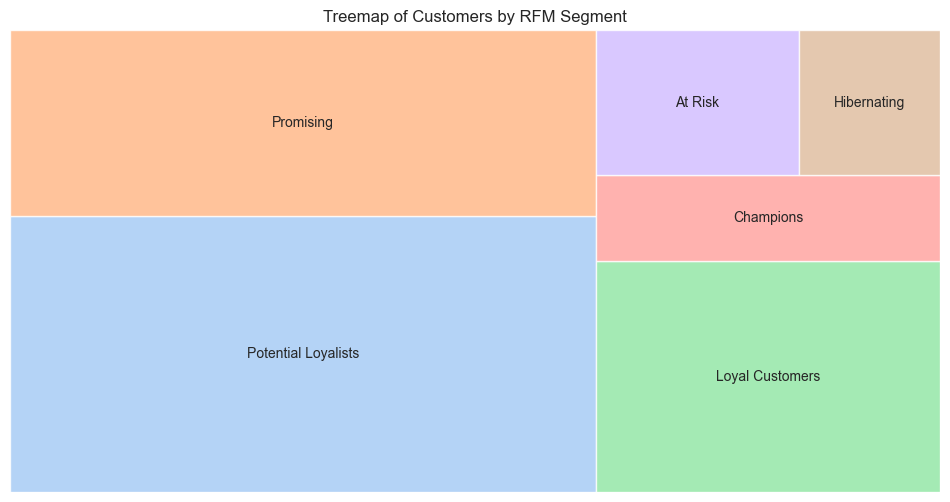

In [44]:
# plot treemap of customer segments
palette = sns.color_palette("pastel", len(customer_segment_counts))

plt.figure(figsize=(12, 6))
squarify.plot(
    sizes=customer_segment_counts['NumberOfCustomers'],
    label=customer_segment_counts['Customer_Segment'],
    color=palette,
    alpha=0.8
)
plt.axis('off')
plt.title('Treemap of Customers by RFM Segment')
plt.show()

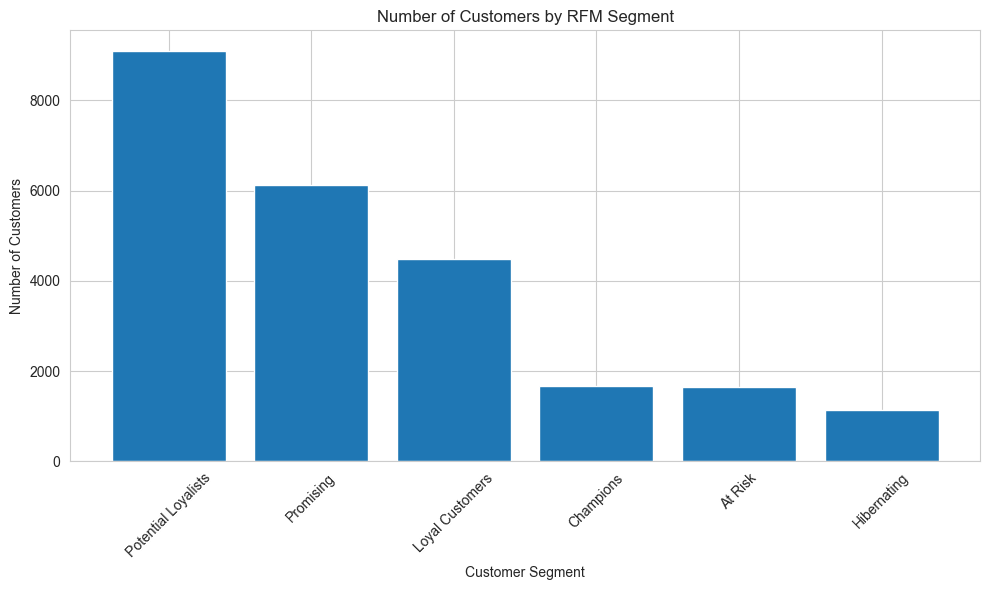

In [45]:
# plot number of customers by segment
plt.figure(figsize=(10, 6))
plt.bar(customer_segment_counts['Customer_Segment'], customer_segment_counts['NumberOfCustomers'])
plt.title('Number of Customers by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

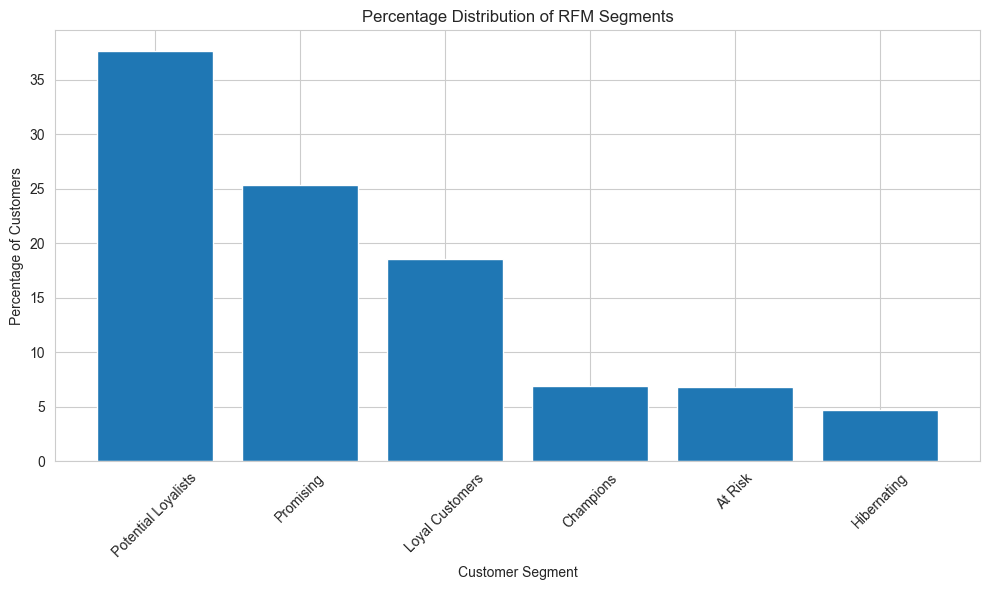

In [46]:
# plot percentage distribution of segments
plt.figure(figsize=(10, 6))
plt.bar(customer_segment_percentages['Customer_Segment'], customer_segment_percentages['Percentage'])
plt.title('Percentage Distribution of RFM Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

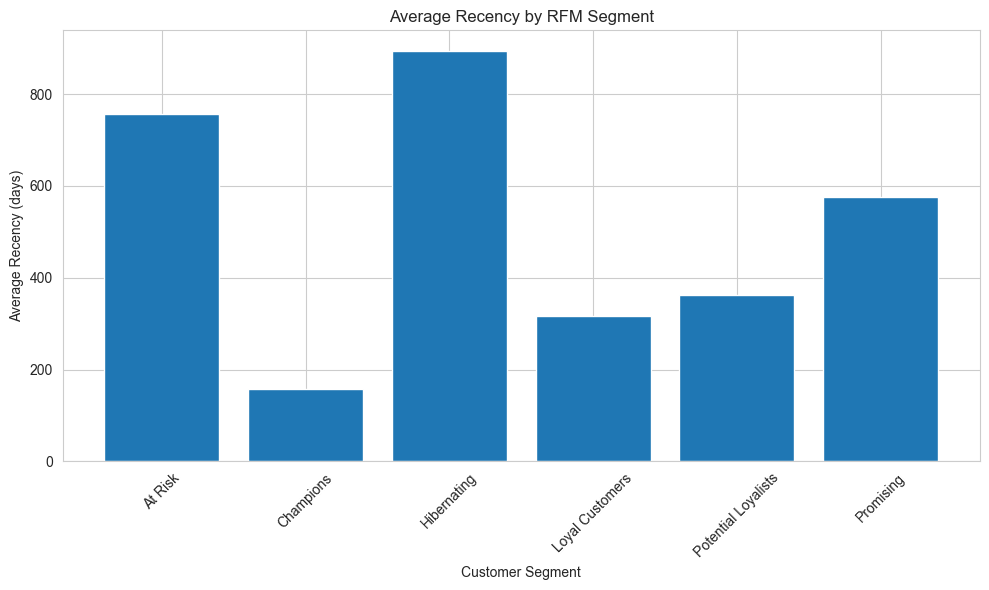

In [47]:
# plot average recency by segment
plt.figure(figsize=(10, 6))
plt.bar(segment_summary['Customer_Segment'], segment_summary['Recency'])
plt.title('Average Recency by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Recency (days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

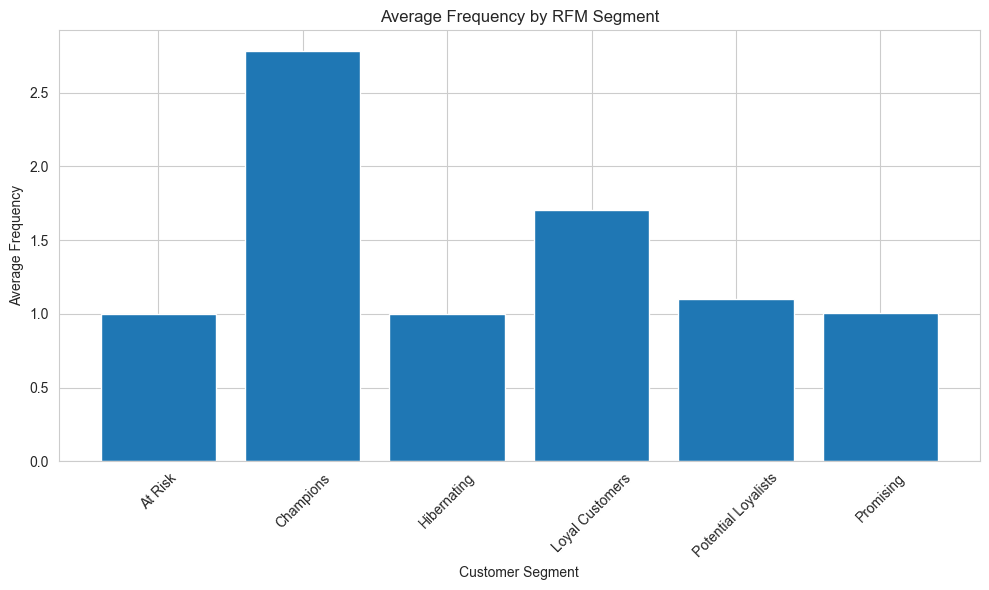

In [48]:
# plot average frequency by segment
plt.figure(figsize=(10, 6))
plt.bar(segment_summary['Customer_Segment'], segment_summary['Frequency'])
plt.title('Average Frequency by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

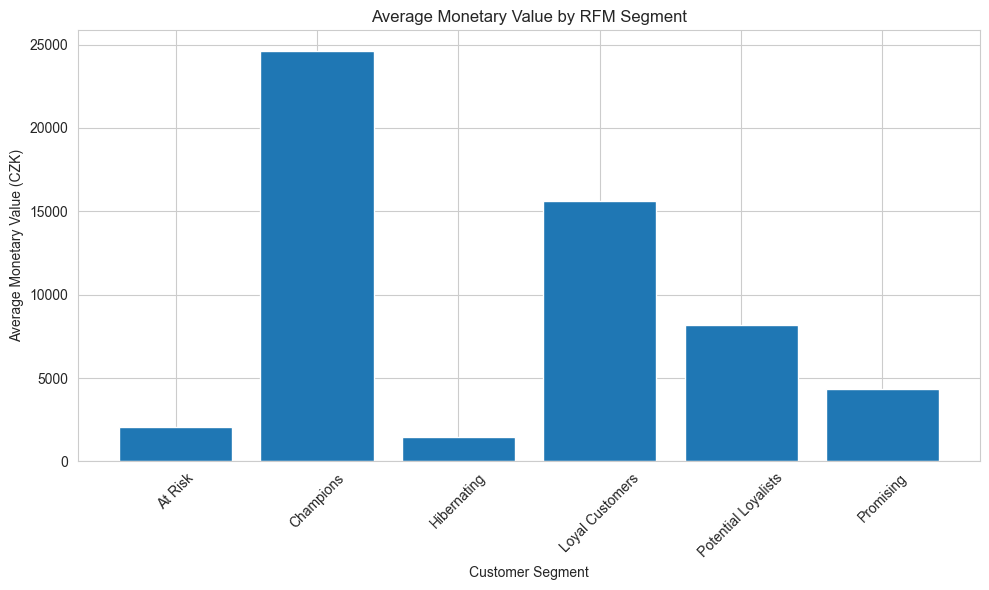

In [49]:
# plot average monetary value by segment
plt.figure(figsize=(10, 6))
plt.bar(segment_summary['Customer_Segment'], segment_summary['Monetary'])
plt.title('Average Monetary Value by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Monetary Value (CZK)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
# display descriptive statistics of the RFM dataset
rfm_df.describe()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Combined
count,24169.000000,24169.000000,24169.000000,24169.000000,24169.000000,24169.000000,24169.000000
mean,445.903554,1.292813,8983.519757,3.002483,1.696181,2.998883,7.697546
std,298.941281,0.873512,9296.819394,1.414094,1.345116,1.415193,2.766760
min,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,3.000000
25%,165.000000,1.000000,2308.000000,2.000000,1.000000,2.000000,6.000000
50%,417.000000,1.000000,5208.000000,3.000000,1.000000,3.000000,7.000000
75%,689.000000,1.000000,12987.000000,4.000000,1.000000,4.000000,10.000000
max,1034.000000,92.000000,142486.000000,5.000000,5.000000,5.000000,15.000000


In [51]:
# save final RFM dataset
rfm_df.to_csv("rfm_df.csv", index=False)

## 4.4.2 K-means Clustering

In [52]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import seaborn as sns

# set plot style
sns.set_style("whitegrid")

In [53]:
# select scaled RFM variables for clustering
X = customer_data_scaled[['Recency', 'Frequency', 'Monetary']].copy()

# preview clustering input
X.head()

,Recency,Frequency,Monetary
0,-1.061838,-0.457406,-0.737092
1,-1.466933,1.436590,1.060849
2,0.896678,-0.457406,-0.004497
3,-0.991533,-0.457406,-0.950679
4,1.305121,-0.457406,-0.297354


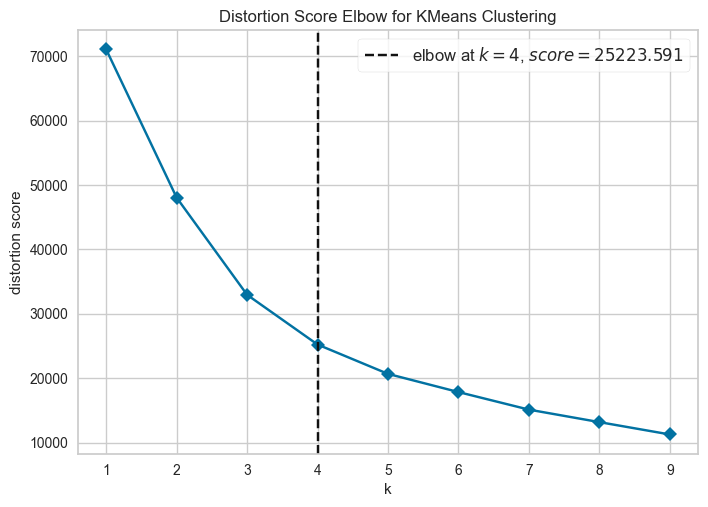

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [54]:
from yellowbrick.cluster import KElbowVisualizer

# use the elbow method to identify a suitable number of clusters
model = KMeans(random_state=42, n_init=10)

visualizer = KElbowVisualizer(
    model,
    k=(1, 10),
    timings=False,
    force_model=True  # <-- toto je fix
)

visualizer.fit(X)
visualizer.show()

In [55]:
# apply K-means clustering with the selected number of clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_data_scaled['Cluster'] = kmeans.fit_predict(X)

# preview assigned clusters
customer_data_scaled.head()

,Customer_id,Recency,Frequency,Monetary,Cluster
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,-1.061838,-0.457406,-0.737092,3
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,-1.466933,1.436590,1.060849,0
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,0.896678,-0.457406,-0.004497,1
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,-0.991533,-0.457406,-0.950679,3
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,1.305121,-0.457406,-0.297354,1


In [56]:
# display cluster centers in scaled space
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Recency', 'Frequency', 'Monetary']
)

cluster_centers

,Recency,Frequency,Monetary
0,-0.191179,1.925316,0.358946
1,1.038646,-0.426204,-0.354487
2,-0.244289,0.004066,1.821184
3,-0.774059,-0.457406,-0.500268


In [57]:
# count customers in each cluster
cluster_counts = customer_data_scaled['Cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'NumberOfCustomers']

# display cluster counts
print(cluster_counts)

   Cluster  NumberOfCustomers
0        0               3828
1        1               7952
2        2               3186
3        3               8719


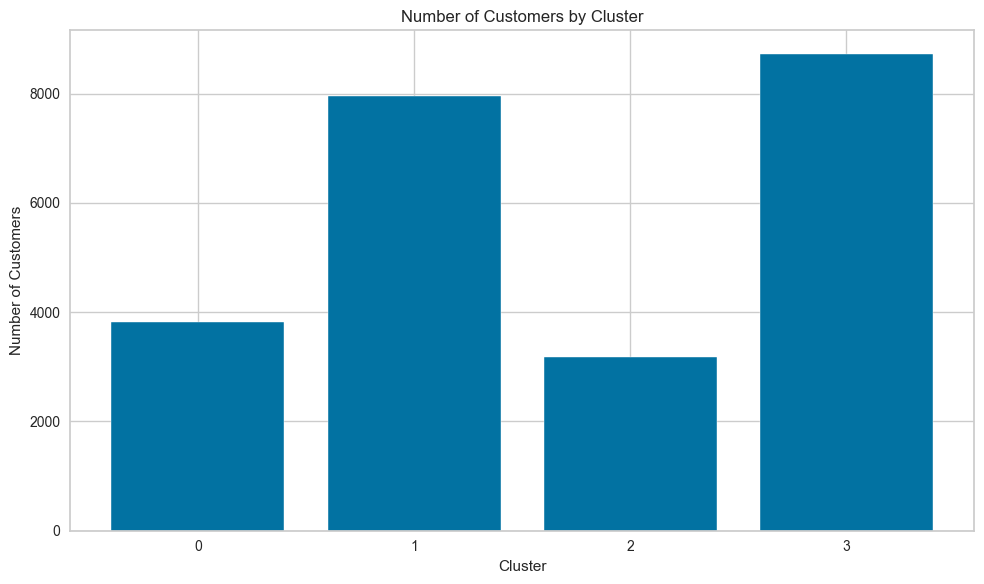

In [58]:
# plot number of customers in each cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_counts['Cluster'].astype(str), cluster_counts['NumberOfCustomers'])
plt.title('Number of Customers by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [59]:
# calculate percentage distribution of clusters
cluster_percentages = customer_data_scaled['Cluster'].value_counts(normalize=True).sort_index().mul(100).reset_index()
cluster_percentages.columns = ['Cluster', 'Percentage']

# display cluster percentages
print(cluster_percentages)

   Cluster  Percentage
0        0   16.162128
1        1   33.573992
2        2   13.451552
3        3   36.812328


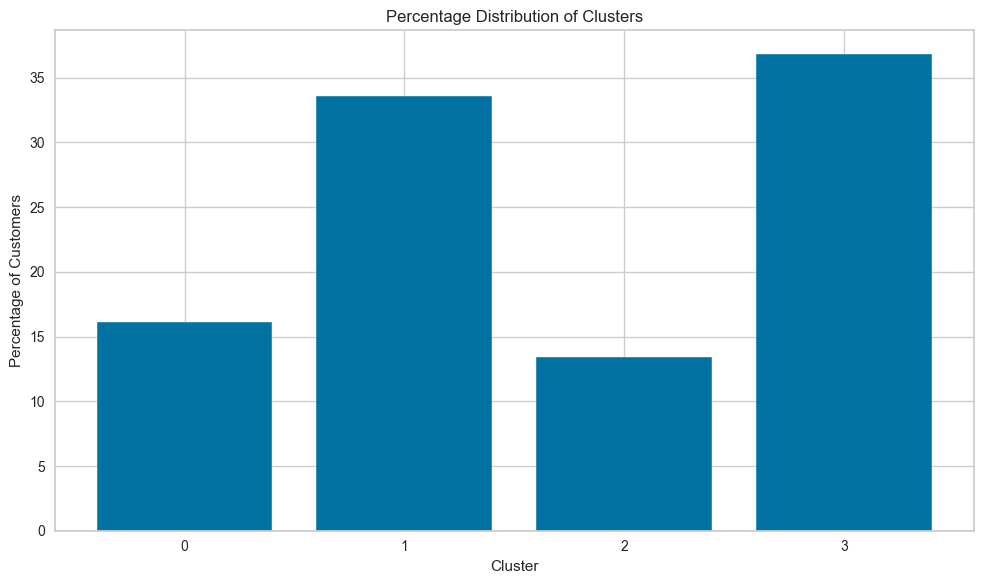

In [60]:
# plot percentage distribution of clusters
plt.figure(figsize=(10, 6))
plt.bar(cluster_percentages['Cluster'].astype(str), cluster_percentages['Percentage'])
plt.title('Percentage Distribution of Clusters')
plt.xlabel('Cluster')
plt.ylabel('Percentage of Customers')
plt.tight_layout()
plt.show()

In [61]:
# merge cluster labels with the original cleaned customer-level dataset
clustered_data = customer_data_clean.merge(
    customer_data_scaled[['Customer_id', 'Cluster']],
    on='Customer_id',
    how='left'
)

# preview merged dataset
clustered_data.head()

,Customer_id,First_Purchase_Date,Last_Purchase_Date,Frequency,Monetary,Recency,Average_Transaction_Value,Customer_Lifetime_Days,Cluster
0,00064b7aa41a5d21c4c9db3507d7ef3b049744429c138e...,2025-06-23 14:26:00,2025-06-23 14:26:00,1,2622.0,130,2622.0,0,3
1,0006857f8cf3cfd85193fb5b01f1f27e5bf797cbac1e99...,2025-10-17 16:58:00,2025-10-23 05:23:00,2,16503.0,9,8251.5,5,0
2,0017437d50a91f8d61117af71d7e9951d35fc87218ade1...,2023-11-16 18:23:00,2023-11-16 18:23:00,1,8278.0,715,8278.0,0,1
3,001d8b397484e2ce67c42250613c10976bea11cc77f413...,2025-06-02 22:12:00,2025-06-02 22:12:00,1,973.0,151,973.0,0,3
4,001e98f5c5d55b6e30d441c4eef719ef2d30347989fc7b...,2023-07-18 06:56:00,2023-07-18 06:56:00,1,6017.0,837,6017.0,0,1


In [62]:
# calculate average customer characteristics by cluster
cluster_summary = clustered_data.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary',
    'Average_Transaction_Value',
    'Customer_Lifetime_Days'
]].mean().reset_index()

# display cluster summary
print(cluster_summary)

   Cluster     Recency  Frequency      Monetary  Average_Transaction_Value  \
0        0  390.439655   2.257837  11078.527691                4905.180773   
1        1  757.324698   1.016097   5581.645121                5549.478873   
2        2  373.824859   1.243879  22379.834275               18847.766478   
3        3  215.997133   1.000000   4448.990825                4448.990825   

   Customer_Lifetime_Days  
0              132.428161  
1                0.249120  
2               26.390458  
3                0.000000  


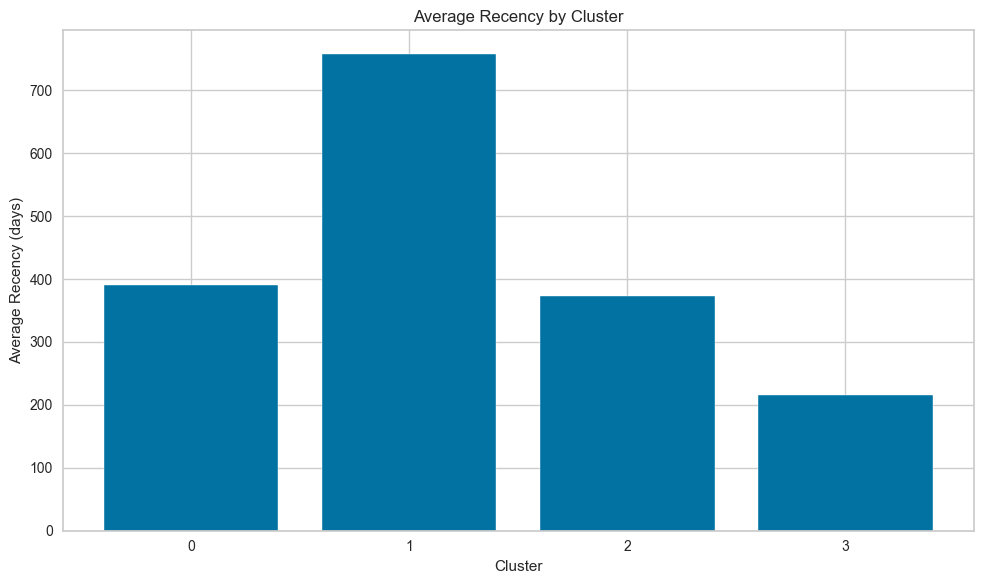

In [63]:
# plot average recency by cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_summary['Cluster'].astype(str), cluster_summary['Recency'])
plt.title('Average Recency by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Recency (days)')
plt.tight_layout()
plt.show()

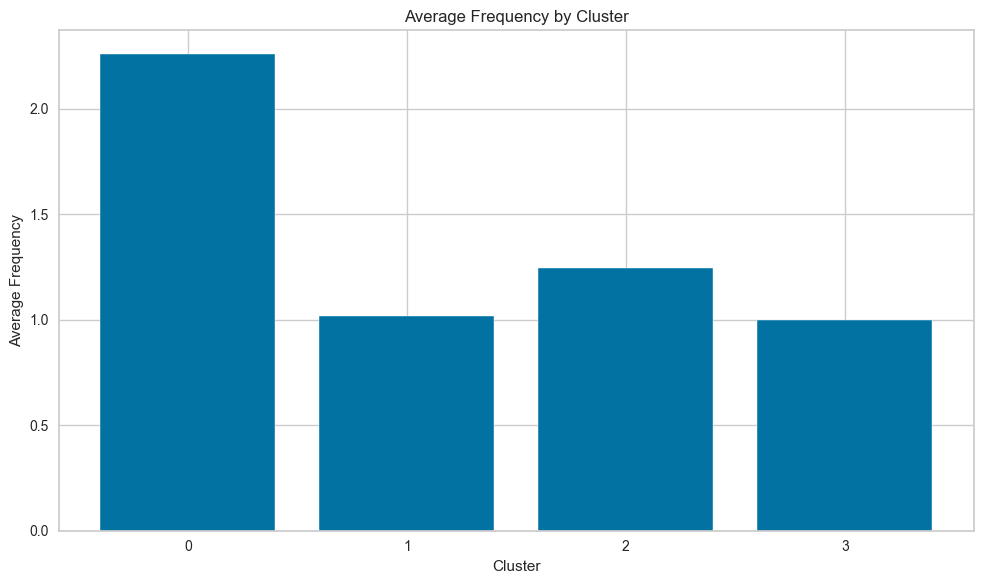

In [64]:
# plot average frequency by cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_summary['Cluster'].astype(str), cluster_summary['Frequency'])
plt.title('Average Frequency by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Frequency')
plt.tight_layout()
plt.show()

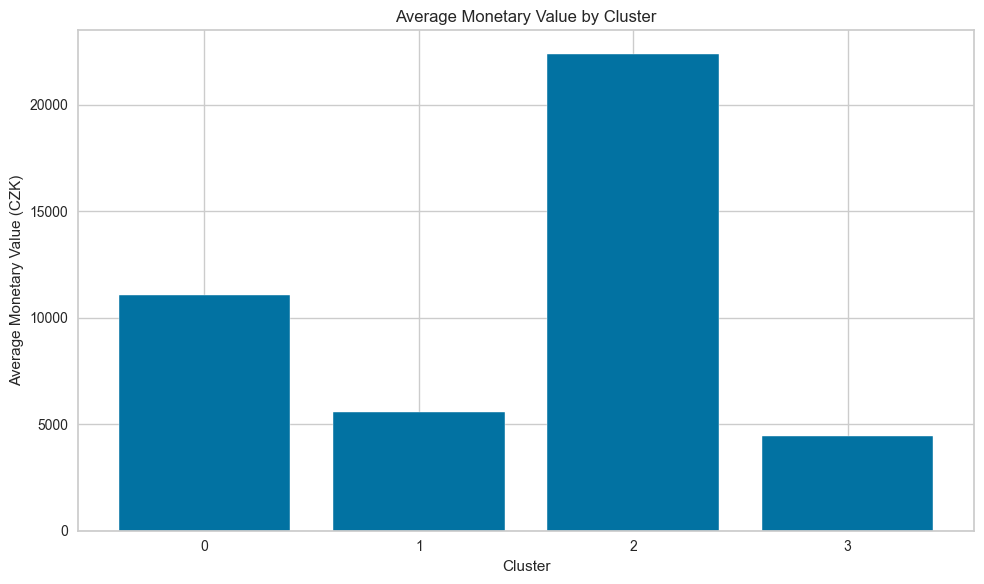

In [65]:
# plot average monetary value by cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_summary['Cluster'].astype(str), cluster_summary['Monetary'])
plt.title('Average Monetary Value by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Monetary Value (CZK)')
plt.tight_layout()
plt.show()

In [66]:
# assign cluster labels (business-friendly names)
def label_cluster(row):
    if row['Cluster'] == 0:
        return 'Inactive Customers'
    elif row['Cluster'] == 1:
        return 'New Customers'
    elif row['Cluster'] == 2:
        return 'Repeat Customers'
    else:
        return 'High-Value Customers'

clustered_data['Cluster_Label'] = clustered_data.apply(label_cluster, axis=1)

In [67]:
# save final clustering dataset
clustered_data.to_csv("clustered_data.csv", index=False)

## 4.4.3 Seasonality Analysis

In [93]:
# SEASONALITY ANALYSIS - SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# copy dataset
seasonality_df = seasonal_data.copy()

# datetime + types
seasonality_df['paid_at'] = pd.to_datetime(seasonality_df['paid_at'], errors='coerce')
seasonality_df['Customer_id'] = seasonality_df['Customer_id'].astype(str)

# merge clusters
seasonality_df = seasonality_df.merge(
    clustered_data[['Customer_id', 'Cluster', 'Cluster_Label']],
    on='Customer_id',
    how='left'
)

# drop missing dates
seasonality_df = seasonality_df.dropna(subset=['paid_at'])

# time features
seasonality_df['Year'] = seasonality_df['paid_at'].dt.year
seasonality_df['Month'] = seasonality_df['paid_at'].dt.month
seasonality_df['Month_Name'] = seasonality_df['paid_at'].dt.month_name()
seasonality_df['YearMonth'] = seasonality_df['paid_at'].dt.to_period('M').astype(str)

# seasonal flags
seasonality_df['Is_Christmas'] = seasonality_df['Month'].isin([11, 12]).astype(int)
seasonality_df['Is_Back_to_School'] = seasonality_df['Month'].isin([8, 9]).astype(int)
seasonality_df['Is_Apple_Launch'] = (seasonality_df['Month'] == 9).astype(int)

# main period
def assign_main_period(month):
    if month in [11, 12]:
        return 'Christmas'
    elif month in [8, 9]:
        return 'Back-to-School'
    else:
        return 'Regular Months'

seasonality_df['Main_Period'] = seasonality_df['Month'].apply(assign_main_period)

# order-level dataset 
seasonality_orders = seasonality_df.drop_duplicates(subset=['order_number']).copy()

# REMOVE LAST INCOMPLETE MONTH

# find the latest date in the order-level dataset
max_date = seasonality_orders['paid_at'].max()

# create the first day of the latest month
last_month_start = pd.Timestamp(max_date.year, max_date.month, 1)

# keep only observations before the last incomplete month
seasonality_orders = seasonality_orders[
    seasonality_orders['paid_at'] < last_month_start
].copy()

# check the latest remaining date
print("Latest remaining date:", seasonality_orders['paid_at'].max())
print("Latest remaining YearMonth:", seasonality_orders['paid_at'].dt.to_period('M').max())

print(seasonality_orders.head())

Latest remaining date: 2025-10-31 20:47:00
Latest remaining YearMonth: 2025-10
   order_number                                        Customer_id    total  \
0        162907  e44cc6393b4083277f5b79548f1cfa4605609826a97994...    349.0   
1        390710  d77a38be6dc0014f85550c2333157e00ac998afdff275e...    399.0   
2        805933  2e9bf21606b5e2ccf9d939a4de2dc2eed19e80207412c1...   1299.0   
3        849845  8cdfe296a00a3a3872a42f8115fda2a6b13ca79035832d...  15180.0   
4       1240002  c901e8ea0c550450511425564a77bb5f63a73e8a0c8f2b...  10588.0   

              paid_at     product_type  Month  Year  Quarter  Cluster  \
0 2025-05-27 09:25:00  product_variant      5  2025        2      0.0   
1 2024-12-24 13:59:00  product_variant     12  2024        4      0.0   
2 2025-05-17 23:39:00          airpods      5  2025        2      0.0   
3 2024-05-04 15:51:00           iphone      5  2024        2      0.0   
4 2024-01-01 10:40:00           iphone      1  2024        1      1.0   

       

   YearMonth  Orders     Revenue  Customers
0    2023-01      41    202161.0         41
1    2023-02      34    251922.0         34
2    2023-03      43    331691.0         43
3    2023-04      39    297799.0         39
4    2023-05      77    514368.0         77
5    2023-06      63    530075.0         63
6    2023-07     537   4104088.0        500
7    2023-08     743   5114105.0        667
8    2023-09     600   4451998.0        534
9    2023-10     549   4127263.0        494
10   2023-11     883   6201012.0        801
11   2023-12    1234   8510390.0       1126
12   2024-01     468   3591426.0        451
13   2024-02     823   6058905.0        744
14   2024-03     920   5750805.0        844
15   2024-04     135    831572.0        132
16   2024-05     626   4266349.0        572
17   2024-06     760   5049658.0        671
18   2024-07     903   5147879.0        785
19   2024-08     858   4862464.0        768
20   2024-09     770   4404309.0        687
21   2024-10     834   5297716.0

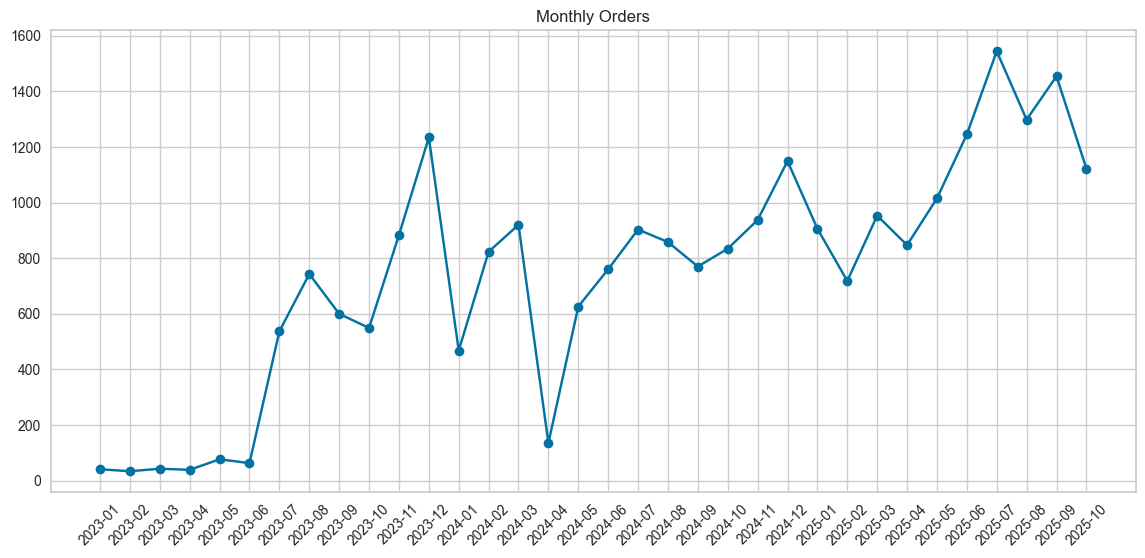

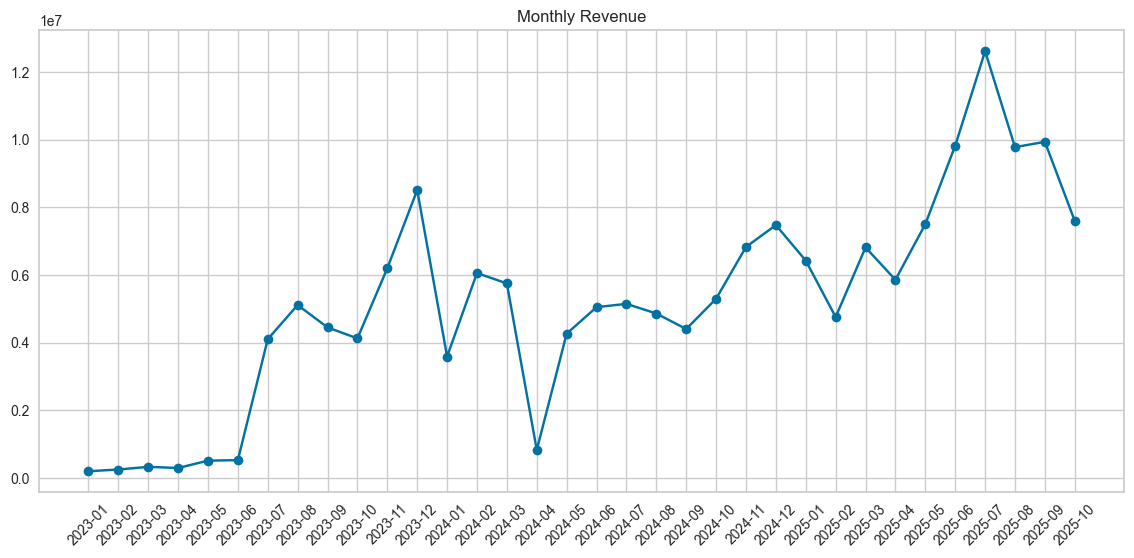

In [94]:
# OVERALL MONTHLY SEASONALITY

monthly_overall = seasonality_orders.groupby('YearMonth').agg(
    Orders=('order_number', 'nunique'),
    Revenue=('total', 'sum'),
    Customers=('Customer_id', 'nunique')
).reset_index()

print(monthly_overall)

# orders
plt.figure(figsize=(14,6))
plt.plot(monthly_overall['YearMonth'], monthly_overall['Orders'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Orders')
plt.show()

# revenue
plt.figure(figsize=(14,6))
plt.plot(monthly_overall['YearMonth'], monthly_overall['Revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.show()

    Month    Year       Orders       Revenue    Customers  Orders_Index  \
0       1  2024.0   471.666667  3.406520e+06   433.000000      0.623588   
1       2  2024.0   525.000000  3.689824e+06   480.000000      0.694100   
2       3  2024.0   638.666667  4.298758e+06   584.666667      0.844378   
3       4  2024.0   340.333333  2.329430e+06   310.666667      0.449953   
4       5  2024.0   572.666667  4.095130e+06   515.666667      0.757120   
5       6  2024.0   689.333333  5.133850e+06   616.000000      0.911365   
6       7  2024.0   994.666667  7.288083e+06   881.333333      1.315044   
7       8  2024.0   966.333333  6.584971e+06   859.333333      1.277585   
8       9  2024.0   941.333333  6.263808e+06   844.666667      1.244533   
9      10  2024.0   835.000000  5.674172e+06   745.666667      1.103950   
10     11  2023.5   910.000000  6.515192e+06   831.500000      1.203107   
11     12  2023.5  1191.500000  7.992502e+06  1084.000000      1.575277   

    Revenue_Index  
0   

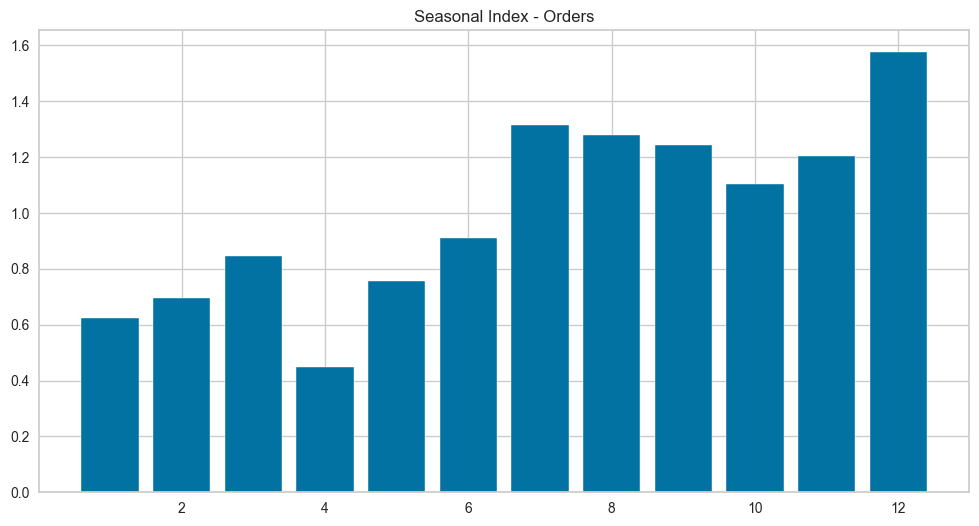

In [95]:
# SEASONAL INDICES

monthly_by_year = seasonality_orders.groupby(['Year','Month']).agg(
    Orders=('order_number','nunique'),
    Revenue=('total','sum'),
    Customers=('Customer_id','nunique')
).reset_index()

monthly_seasonality = monthly_by_year.groupby('Month').mean().reset_index()

# overall averages
avg_orders = monthly_seasonality['Orders'].mean()
avg_revenue = monthly_seasonality['Revenue'].mean()

# indices
monthly_seasonality['Orders_Index'] = monthly_seasonality['Orders'] / avg_orders
monthly_seasonality['Revenue_Index'] = monthly_seasonality['Revenue'] / avg_revenue

print(monthly_seasonality)

# plot
plt.figure(figsize=(12,6))
plt.bar(monthly_seasonality['Month'], monthly_seasonality['Orders_Index'])
plt.title("Seasonal Index - Orders")
plt.show()

      Main_Period  Orders      Revenue  Customers
0  Back-to-School    5723   38546339.0       4913
1       Christmas    4203   29015388.0       3694
2  Regular Months   15202  107747300.0      12685


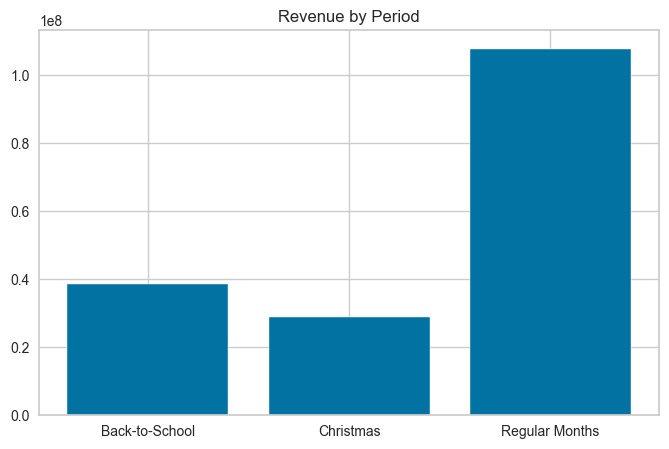

In [96]:
# SEASONAL PERIOD COMPARISON

period_summary = seasonality_orders.groupby('Main_Period').agg(
    Orders=('order_number','nunique'),
    Revenue=('total','sum'),
    Customers=('Customer_id','nunique')
).reset_index()

print(period_summary)

plt.figure(figsize=(8,5))
plt.bar(period_summary['Main_Period'], period_summary['Revenue'])
plt.title("Revenue by Period")
plt.show()

  YearMonth       Cluster_Label  Orders   Revenue  Customers
0   2023-01  Inactive Customers       8   68352.0          8
1   2023-01       New Customers      28   52643.0         28
2   2023-01    Repeat Customers       4   78667.0          4
3   2023-02  Inactive Customers      17  159890.0         17
4   2023-02       New Customers      12   29809.0         12


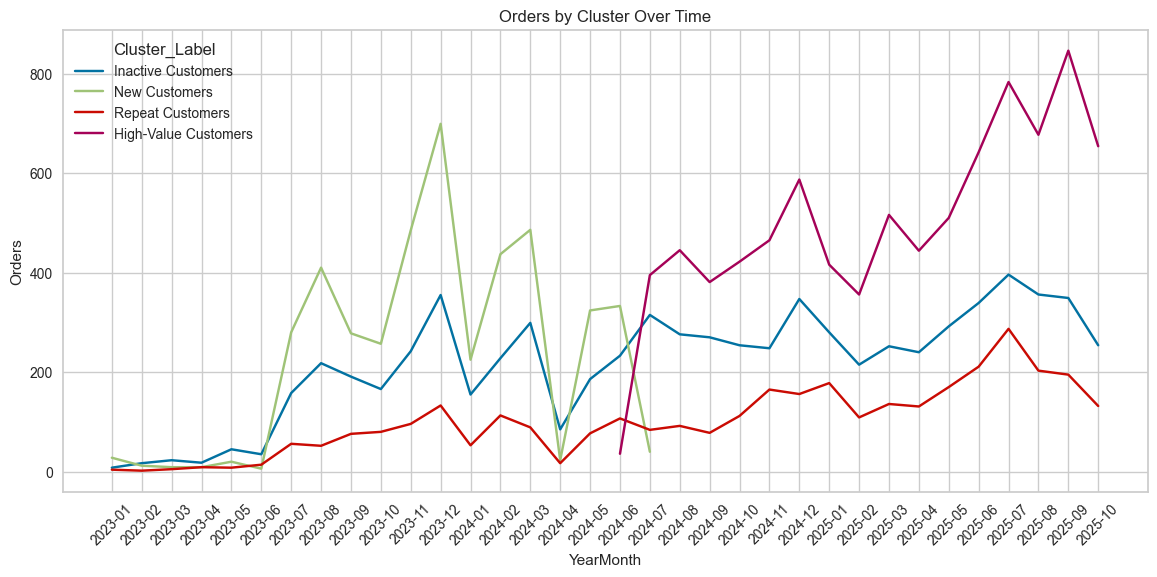

In [97]:
# MONTHLY BY CLUSTER

cluster_monthly = seasonality_orders.groupby(['YearMonth','Cluster_Label']).agg(
    Orders=('order_number','nunique'),
    Revenue=('total','sum'),
    Customers=('Customer_id','nunique')
).reset_index()

print(cluster_monthly.head())

plt.figure(figsize=(14,6))
sns.lineplot(data=cluster_monthly, x='YearMonth', y='Orders', hue='Cluster_Label')
plt.xticks(rotation=45)
plt.title("Orders by Cluster Over Time")
plt.show()

           Cluster_Label     Main_Period  Orders     Revenue  Order_Share_%
0   High-Value Customers  Back-to-School    2349  10476085.0      27.393586
1   High-Value Customers       Christmas    1052   4215202.0      12.268222
2   High-Value Customers  Regular Months    5174  23567269.0      60.338192
3     Inactive Customers  Back-to-School    1660   8183099.0      22.600408
4     Inactive Customers       Christmas    1192   5605565.0      16.228727
5     Inactive Customers  Regular Months    4493  22196458.0      61.170865
6          New Customers  Back-to-School     688   3779052.0      15.776198
7          New Customers       Christmas    1184   6712993.0      27.149736
8          New Customers  Regular Months    2489  12782981.0      57.074066
9       Repeat Customers  Back-to-School     696  12394053.0      20.291545
10      Repeat Customers       Christmas     550  10056166.0      16.034985
11      Repeat Customers  Regular Months    2184  39361179.0      63.673469


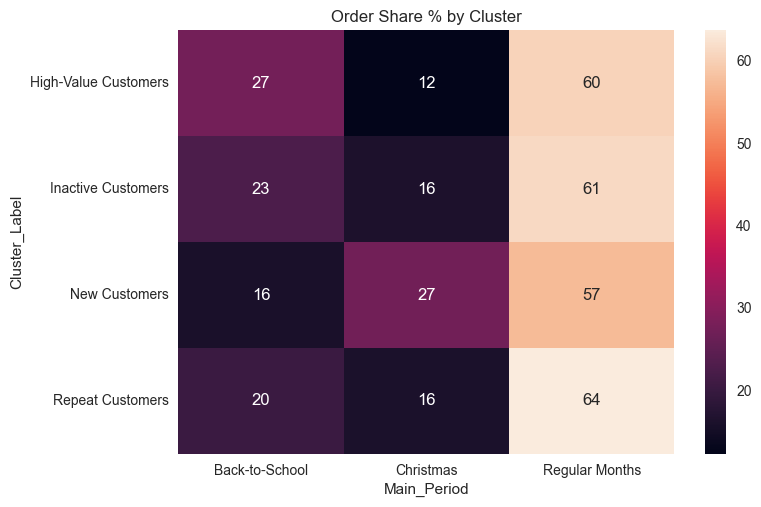

In [98]:
# SEASONAL CONCENTRATION BY CLUSTER

cluster_period = seasonality_orders.groupby(['Cluster_Label','Main_Period']).agg(
    Orders=('order_number','nunique'),
    Revenue=('total','sum')
).reset_index()

# percentage share
cluster_period['Order_Share_%'] = cluster_period.groupby('Cluster_Label')['Orders'].transform(
    lambda x: (x / x.sum()) * 100
)

print(cluster_period)

pivot = cluster_period.pivot(
    index='Cluster_Label',
    columns='Main_Period',
    values='Order_Share_%'
)

sns.heatmap(pivot, annot=True)
plt.title("Order Share % by Cluster")
plt.show()

          Cluster_Label Christmas_Flag  Orders     Revenue
0  High-Value Customers      Christmas    1052   4215202.0
1  High-Value Customers          Other    7523  34043354.0
2    Inactive Customers      Christmas    1192   5605565.0
3    Inactive Customers          Other    6153  30379557.0
4         New Customers      Christmas    1184   6712993.0
5         New Customers          Other    3177  16562033.0
6      Repeat Customers      Christmas     550  10056166.0
7      Repeat Customers          Other    2880  51755232.0


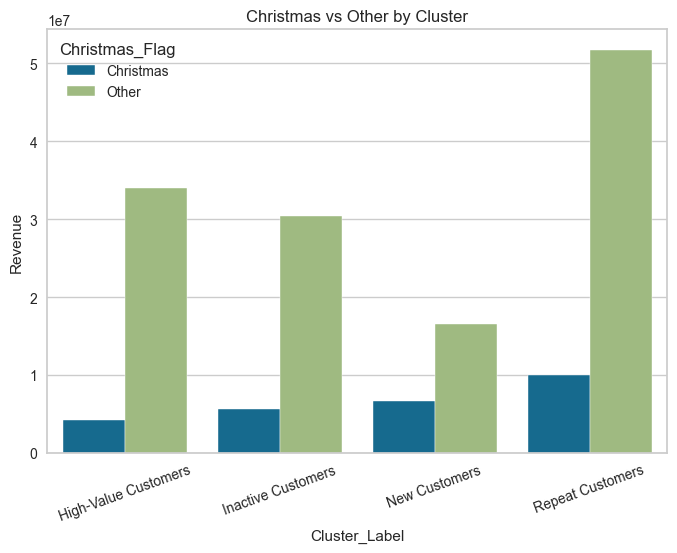

In [99]:
# CHRISTMAS VS OTHER

seasonality_orders['Christmas_Flag'] = np.where(
    seasonality_orders['Month'].isin([11,12]),
    'Christmas',
    'Other'
)

christmas_summary = seasonality_orders.groupby(['Cluster_Label','Christmas_Flag']).agg(
    Orders=('order_number','nunique'),
    Revenue=('total','sum')
).reset_index()

print(christmas_summary)

sns.barplot(data=christmas_summary, x='Cluster_Label', y='Revenue', hue='Christmas_Flag')
plt.title("Christmas vs Other by Cluster")
plt.xticks(rotation=20)
plt.show()

          Cluster_Label BTS_Flag  Orders     Revenue
0  High-Value Customers      BTS    2349  10476085.0
1  High-Value Customers    Other    6226  27782471.0
2    Inactive Customers      BTS    1660   8183099.0
3    Inactive Customers    Other    5685  27802023.0
4         New Customers      BTS     688   3779052.0
5         New Customers    Other    3673  19495974.0
6      Repeat Customers      BTS     696  12394053.0
7      Repeat Customers    Other    2734  49417345.0


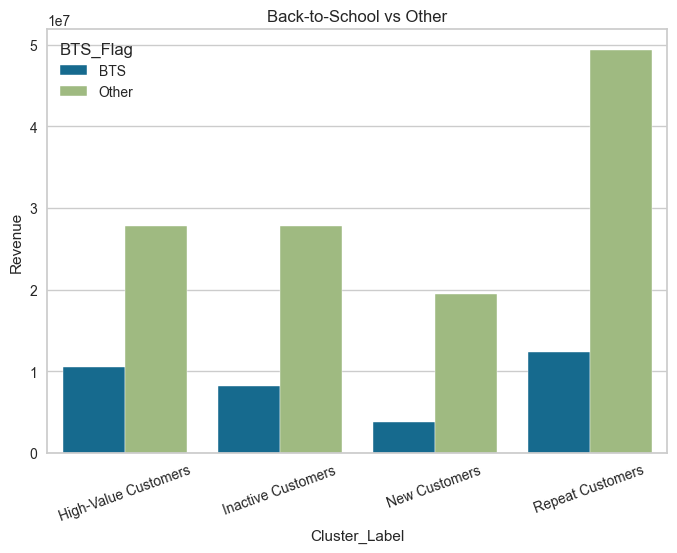

In [100]:
# BACK TO SCHOOL

seasonality_orders['BTS_Flag'] = np.where(
    seasonality_orders['Month'].isin([8,9]),
    'BTS',
    'Other'
)

bts_summary = seasonality_orders.groupby(['Cluster_Label','BTS_Flag']).agg(
    Orders=('order_number','nunique'),
    Revenue=('total','sum')
).reset_index()

print(bts_summary)

sns.barplot(data=bts_summary, x='Cluster_Label', y='Revenue', hue='BTS_Flag')
plt.title("Back-to-School vs Other")
plt.xticks(rotation=20)
plt.show()